In [1]:
!pip install -q -U transformers
!pip install -q -U datasets
!pip install -q -U accelerate
!pip install -q -U evaluate
!pip install -q -U scikit-learn
!pip install -q -U wandb
!pip install -q sentencepiece

## **Import Libraries**

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

import wandb

In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: nguyenthu-m462004 (nguyenthu-m462004-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Config**

In [5]:
# DATA

DATASET_PATH = "/content/drive/MyDrive/5.SemanticMapping/scope_dataset/scope_dataset_balanced.csv"

TEXT_COLUMN = "text"
LABEL_COLUMN = "scope"

# MODEL

MODEL_NAME = "climatebert/distilroberta-base-climate-f"

OUTPUT_DIR = "/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope"

# TRAINING

MAX_LENGTH = 256

BATCH_SIZE = 16

LR = 2e-5

WEIGHT_DECAY = 0.01

NUM_EPOCHS = 20

SEEDS = [42, 123, 2026, 3407, 8888]

## **Seed**

In [6]:
def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

## **Load dataset**

In [7]:
df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()

(4838, 14)


,block_id,page,text,type,confidence,semantic_standard,semantic_document,semantic_score,matched_chunk,matched_page,matched_document,scope,bbox,quality_score
0,6196,hoa_phat_group_jsc_2025_p037_jpg.rf.52ccc19901...,"However, the large-scale adoption of these sol...",text,0.996382,ghg-protocol-revised,ghg-protocol-revised,0.984993,", use and disposal of refrigeration and air- c...",46,ghg-protocol-revised,Scope 1,NaN,3.369986
1,11859,vietnam_airlines_jsc_2024_p010_jpg.rf.37067598...,"As the flag air carrier of Vietnam, VNA is re...",text,0.996859,ghg-protocol-revised,ghg-protocol-revised,0.984196,. G U I D A N C E Business Goals and Inventory...,16,ghg-protocol-revised,Scope 1,NaN,3.368391
2,8005,masan_group_corp_2024_p080_jpg.rf.85cd3d38b052...,(i) These balances represented interest income...,text,0.982753,ghg-protocol-revised,ghg-protocol-revised,0.983702,. (Chapter 10) Mobile combustion Burning of fu...,102,ghg-protocol-revised,Scope 1,NaN,3.367404
3,13145,vietnam_national_petroleum_group_2024_p068_jpg...,Petrolimex has been always paying attention to...,text,0.996503,GRI 14,GRI 14_ Mining Sector 2024 V1.1,0.982823,". Note 2: The ILO Minimum Age Convention, 1973...",73,GRI 14_ Mining Sector 2024 V1.1,Scope 1,NaN,3.365646
4,11238,vicostone_jsc_2024_p149_jpg.rf.99580ae7c72d002...,Vicostone completed assessing 100% key supplie...,text,0.996553,GRI 13,GRI 13_ Agriculture Aquaculture and Fishing Se...,0.981044,. Describe actions taken to support the econom...,61,GRI 13_ Agriculture Aquaculture and Fishing Se...,Scope 1,NaN,3.362088


In [8]:
assert df["scope"].isnull().sum() == 0

In [9]:
df["scope"].value_counts()

,count
scope,
Other,1700
Scope 3,1138
Scope 2,1000
Scope 1,1000


In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
# Keep text + label only
df = df[
    [
        "text",
        "scope"
    ]
].copy()

In [12]:
# Delete empty text
df = df.dropna(subset=["text"])

df["text"] = df["text"].astype(str)

df = df[df["text"].str.strip() != ""]

## **Label Mapping**

In [13]:
label2id = {

    "Other":0,

    "Scope 1":1,

    "Scope 2":2,

    "Scope 3":3

}

id2label = {v:k for k,v in label2id.items()}

In [14]:
# Encode label
df["label"] = df["scope"].map(label2id)

In [15]:
df.head()

,text,scope,label
0,"In each building, depending on the conditions ...",Other,0
1,4.Risks\nThe 2021 - 2025 period represents a t...,Scope 3,3
2,Boost individual and organizational performance.,Other,0
3,Year 2014: 21.97 million kWh/year (an increase...,Scope 2,2
4,Product structure shifts: Focus on uniquely de...,Scope 2,2


In [16]:
print(df["label"].value_counts())

label
0    1700
3    1138
2    1000
1    1000
Name: count, dtype: int64


In [17]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


## **Train / Validation / Test**

In [18]:
SPLIT_SEED = 42

train_df, temp_df = train_test_split(

    df,

    test_size=0.2,

    stratify=df["label"],

    random_state=SPLIT_SEED

)

valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=SPLIT_SEED

)

## **Convert to HuggingFace Dataset**

In [19]:
train_dataset = Dataset.from_pandas(train_df)

valid_dataset = Dataset.from_pandas(valid_df)

test_dataset = Dataset.from_pandas(test_df)

In [20]:
if "__index_level_0__" in train_dataset.column_names:
    train_dataset = train_dataset.remove_columns(["__index_level_0__"])

if "__index_level_0__" in valid_dataset.column_names:
    valid_dataset = valid_dataset.remove_columns(["__index_level_0__"])

if "__index_level_0__" in test_dataset.column_names:
    test_dataset = test_dataset.remove_columns(["__index_level_0__"])

In [21]:
# Check
print(train_dataset)

print(valid_dataset)

print(test_dataset)

Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 3870
})
Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 484
})
Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 484
})


In [22]:
print(train_dataset.features)

{'text': Value('string'), 'scope': Value('string'), 'label': Value('int64')}


## **Tokenizer**

In [23]:
print("=" * 60)
print("Loading ClimateBERT...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer.model_max_length)
print(tokenizer.vocab_size)

Loading ClimateBERT...
512
50265


## **Tokenize Dataset**

In [24]:
def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        max_length=MAX_LENGTH,

        padding=False,

        return_attention_mask=True
    )


train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Map:   0%|          | 0/3870 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

In [25]:
# check token length
lengths = []

for x in train_dataset:

    lengths.append(len(x["input_ids"]))

print("Average:", np.mean(lengths))
print("Maximum:", np.max(lengths))

Average: 86.2687338501292
Maximum: 256


(array([212., 381., 354., 286., 199., 171., 152., 126., 144.,  99.,  95.,
         91.,  86., 100.,  74.,  70.,  89.,  49.,  45.,  85.,  80.,  29.,
         33.,  59.,  34.,  34.,  49.,  36.,  43.,  35.,  21.,  32.,  23.,
         25.,  22.,  23.,   7.,  36.,  22., 319.]),
 array([  4. ,  10.3,  16.6,  22.9,  29.2,  35.5,  41.8,  48.1,  54.4,
         60.7,  67. ,  73.3,  79.6,  85.9,  92.2,  98.5, 104.8, 111.1,
        117.4, 123.7, 130. , 136.3, 142.6, 148.9, 155.2, 161.5, 167.8,
        174.1, 180.4, 186.7, 193. , 199.3, 205.6, 211.9, 218.2, 224.5,
        230.8, 237.1, 243.4, 249.7, 256. ]),
 <BarContainer object of 40 artists>)

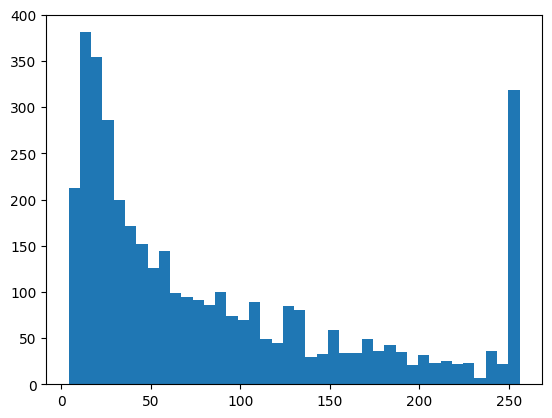

In [26]:
import matplotlib.pyplot as plt
plt.hist(lengths,bins=40)

## **Compute Metrics**

In [27]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

Check Transformers Version

In [28]:
import transformers
import inspect

print(transformers.__version__)

print(inspect.signature(TrainingArguments))

5.13.1
(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_c

# **Fine-tune ClimateBERT**

In [29]:
from transformers.trainer_utils import get_last_checkpoint

In [30]:
all_results = []

best_f1 = -1
best_seed = None
best_trainer = None
best_checkpoint = None

for seed in SEEDS:

    print("=" * 60)
    print(f"Training with seed = {seed}")
    print("=" * 60)

    set_seed(seed)

    # ======================================================
    # Load ClimateBERT
    # ======================================================

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # ======================================================
    # Training Arguments
    # ======================================================

    training_args = TrainingArguments(

        output_dir=os.path.join(
            OUTPUT_DIR,
            f"seed_{seed}"
        ),

        do_train=True,
        do_eval=True,

        eval_strategy="epoch",
        save_strategy="epoch",

        logging_strategy="epoch",
        logging_steps=50,

        learning_rate=LR,

        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,

        num_train_epochs=NUM_EPOCHS,

        weight_decay=WEIGHT_DECAY,

        optim="adamw_torch",

        load_best_model_at_end=True,

        metric_for_best_model="macro_f1",

        greater_is_better=True,

        save_total_limit=1,

        report_to="wandb",

        run_name=f"seed_{seed}",

        fp16=torch.cuda.is_available(),

        seed=seed,
    )

    # ======================================================
    # Trainer
    # ======================================================

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_dataset,

        eval_dataset=valid_dataset,

        processing_class=tokenizer,

        data_collator=data_collator,

        compute_metrics=compute_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    # ======================================================
    # WandB
    # ======================================================

    wandb.init(

        project="climatebert-scope",

        name=f"seed_{seed}",

        config={

            "seed": seed,

            "model_name": MODEL_NAME,

            "batch_size": BATCH_SIZE,

            "learning_rate": LR,

            "max_length": MAX_LENGTH,

            "weight_decay": WEIGHT_DECAY,

            "epochs": NUM_EPOCHS,

            "train_size": len(train_dataset),

            "valid_size": len(valid_dataset),

            "test_size": len(test_dataset),

            "class_distribution": train_df["scope"].value_counts().to_dict()
        }
    )

    checkpoint_dir = os.path.join(
        OUTPUT_DIR,
        f"seed_{seed}"
    )

    completed_flag = os.path.join(
        checkpoint_dir,
        "completed.txt"
    )

    if os.path.exists(completed_flag):
        print(f"Seed {seed} already finished. Skip.")
        continue
    last_checkpoint = None

    if os.path.isdir(checkpoint_dir):
        last_checkpoint = get_last_checkpoint(checkpoint_dir)

    if last_checkpoint is not None:

        print("=" * 60)
        print(f"Resume from: {last_checkpoint}")
        print("=" * 60)

        trainer.train(
            resume_from_checkpoint=last_checkpoint
        )

    else:

        trainer.train()

    # ======================================================
    # Train
    # ======================================================

    trainer.save_state()

    train_metrics = trainer.evaluate(
        eval_dataset=train_dataset,
        metric_key_prefix="train"
    )

    # ======================================================
    # Validation
    # ======================================================

    val_metrics = trainer.evaluate(
        eval_dataset=valid_dataset,
        metric_key_prefix="eval"
    )

    # ======================================================
    # Test
    # ======================================================
    test_metrics = trainer.evaluate(
        eval_dataset=test_dataset,
        metric_key_prefix="test"
    )

    # ======================================================
    # Save Results
    # ======================================================

    result = {
        "seed": seed,
        **train_metrics,
        **val_metrics,
        **test_metrics
    }

    all_results.append(result)

    wandb.log(result)

    # ======================================================
    # Save Best Model
    # ======================================================

    if val_metrics["eval_macro_f1"] > best_f1:

        best_f1 = val_metrics["eval_macro_f1"]

        best_seed = seed

        best_trainer = trainer

        best_checkpoint = trainer.state.best_model_checkpoint

    wandb.finish()

# ==========================================================
# Save Best Model
# ==========================================================

BEST_MODEL_DIR = os.path.join(
    OUTPUT_DIR,
    "best_scope_classifier"
)

best_trainer.save_model(BEST_MODEL_DIR)

tokenizer.save_pretrained(BEST_MODEL_DIR)

print("=" * 60)
print("Training Finished")
print("=" * 60)

print(f"Best Seed            : {best_seed}")
print(f"Best Validation F1   : {best_f1:.4f}")
print(f"Best Checkpoint      : {best_checkpoint}")
print(f"Best model saved to  : {BEST_MODEL_DIR}")

Training with seed = 42


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.833593,0.448190,0.845041,0.862013,0.838181,0.847468,0.850260,0.845041,0.844686
2,0.298731,0.272658,0.915289,0.927524,0.909925,0.917306,0.918522,0.915289,0.915297
3,0.157307,0.237264,0.933884,0.937365,0.936958,0.936372,0.934572,0.933884,0.933498
4,0.093055,0.256877,0.931818,0.928595,0.941158,0.933803,0.933555,0.931818,0.931514
5,0.050491,0.264486,0.938017,0.935075,0.948460,0.940493,0.940381,0.938017,0.937702
6,0.030843,0.237429,0.948347,0.949124,0.952201,0.950537,0.948121,0.948347,0.948121
7,0.016492,0.292579,0.958678,0.961726,0.959554,0.960378,0.958718,0.958678,0.958443
8,0.008088,0.349144,0.938017,0.935719,0.947015,0.940487,0.939768,0.938017,0.937861
9,0.008182,0.292437,0.960744,0.964188,0.961024,0.962356,0.960799,0.960744,0.960516
10,0.004949,0.287181,0.952479,0.954462,0.955142,0.954636,0.952315,0.952479,0.952245


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.023665,0.258928,6,0.946281,0.950784,0.947949,0.948957,0.946664,0.946281,0.946070


eval/accuracy,▁▆▇█▇██
eval/loss,█▂▁▂▅▂▂
eval/macro_f1,▁▆██▇██
eval/macro_precision,▁▆▇█▇▇█
eval/macro_recall,▁▆█████
eval/runtime,▃▂▄▁▂▇█
eval/samples_per_second,▆▇▅█▇▂▁
eval/steps_per_second,▆▇▅█▇▂▁
eval/weighted_f1,▁▆▇█▇██
eval/weighted_precision,▁▆▇█▇██
+49,...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Finished
Best Seed            : 42
Best Validation F1   : 0.9624
Best Checkpoint      : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/seed_42/checkpoint-2178
Best model saved to  : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier


training_config.json

In [31]:
import json
training_config = {

    "model_name": MODEL_NAME,
    "best_seed": best_seed,
    "best_validation_f1": float(best_f1),
    "best_checkpoint": best_checkpoint,

    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_length": MAX_LENGTH,
    "optimizer": "AdamW",

    "train_size": len(train_df),
    "valid_size": len(valid_df),
    "test_size": len(test_df)

}

with open(

    os.path.join(

        BEST_MODEL_DIR,

        "training_config.json"

    ),

    "w"

) as f:

    json.dump(
        training_config,
        f,
        indent=4
    )

label_mapping.json

In [32]:
with open(

    os.path.join(

        BEST_MODEL_DIR,

        "label_mapping.json"

    ),

    "w"

) as f:

    json.dump(

        {

            "label2id": label2id,

            "id2label": id2label

        },

        f,

        indent=4

    )

training_summary.csv

In [33]:
summary_df = pd.DataFrame(all_results)

summary_df.to_csv(

    os.path.join(

        BEST_MODEL_DIR,

        "training_summary.csv"

    ),

    index=False

)

results_summary.csv

In [34]:
results_summary = pd.DataFrame({

    "Metric":[

        "accuracy",
        "precision",
        "recall",
        "macro_f1",
        "weighted_f1"

    ],

    "Mean":[

        summary_df["eval_accuracy"].mean(),
        summary_df["eval_macro_precision"].mean(),
        summary_df["eval_macro_recall"].mean(),
        summary_df["eval_macro_f1"].mean(),
        summary_df["eval_weighted_f1"].mean()

    ],

    "Std":[

        summary_df["eval_accuracy"].std(),
        summary_df["eval_macro_precision"].std(),
        summary_df["eval_macro_recall"].std(),
        summary_df["eval_macro_f1"].std(),
        summary_df["eval_weighted_f1"].std()

    ]

})

results_summary.to_csv(

    os.path.join(

        BEST_MODEL_DIR,

        "results_summary.csv"

    ),

    index=False

)

classification_report.txt

In [35]:
wandb.init(project="climatebert-scope", resume=True)
predictions = best_trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [36]:
report = classification_report(

    y_true,

    y_pred,

    target_names=[

        id2label[i]

        for i in range(len(id2label))

    ]

)

with open(

    os.path.join(

        BEST_MODEL_DIR,

        "classification_report.txt"

    ),

    "w",

    encoding="utf-8"

) as f:

    f.write(report)

classification_report.json

In [37]:
import json

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=[
        id2label[i]
        for i in range(len(id2label))
    ],
    output_dict=True,
    zero_division=0
)

with open(
    os.path.join(
        BEST_MODEL_DIR,
        "classification_report.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report_dict,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved classification_report.json")

Saved classification_report.json


confusion_matrix.png

In [38]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax)
plt.tight_layout()
cm_path = os.path.join(BEST_MODEL_DIR, "confusion_matrix.png")
plt.savefig(cm_path)
plt.close()

confusion_matrix.csv

In [39]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{x}" for x in label2id.keys()],
    columns=[f"Pred_{x}" for x in label2id.keys()]
)

cm_df.to_csv(
    os.path.join(
        BEST_MODEL_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)

print("Saved confusion_matrix.csv")

Saved confusion_matrix.csv


predictions.csv

In [40]:
import torch
import torch.nn.functional as F

# Convert logits -> probabilities
probs = F.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

confidence = probs.max(axis=1)

predictions_df = pd.DataFrame({

    "text": test_df["text"].reset_index(drop=True),

    "true_id": y_true,

    "pred_id": y_pred,

    "true_label": [
        id2label[i]
        for i in y_true
    ],

    "pred_label": [
        id2label[i]
        for i in y_pred
    ],

    "confidence": confidence,

    "correct": (
        y_true == y_pred
    )

})

predictions_path = os.path.join(
    BEST_MODEL_DIR,
    "predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved predictions to: {predictions_path}")

Saved predictions to: /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier/predictions.csv


README.txt

In [41]:
from datetime import datetime
import platform
import transformers
import torch

In [42]:
readme = f"""
============================================================
ClimateBERT Scope Classifier
============================================================

Dataset
-------
{DATASET_PATH}

Model
-----
{MODEL_NAME}

Tokenizer
---------
{MODEL_NAME}

Number of Classes
-----------------
{len(label2id)}

Labels
------
0 : Other
1 : Scope 1
2 : Scope 2
3 : Scope 3

Training Information
--------------------
Training Date : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Best Seed : {best_seed}

Best Validation F1 : {best_f1:.4f}

Best Checkpoint : {best_checkpoint}

Hyperparameters
---------------
Epochs        : {NUM_EPOCHS}
Batch Size    : {BATCH_SIZE}
Learning Rate : {LR}
Weight Decay  : {WEIGHT_DECAY}
Max Length    : {MAX_LENGTH}

Environment
-----------
Python          : {platform.python_version()}
PyTorch         : {torch.__version__}
Transformers    : {transformers.__version__}
CUDA Available  : {torch.cuda.is_available()}
CUDA Version    : {torch.version.cuda}
Device          : {"GPU" if torch.cuda.is_available() else "CPU"}

Saved Files
-----------
config.json
model.safetensors
tokenizer.json
tokenizer_config.json
special_tokens_map.json

training_config.json
label_mapping.json

training_summary.csv
results_summary.csv
predictions.csv

classification_report.txt
classification_report.json

confusion_matrix.png
confusion_matrix.csv

README.txt

============================================================
This folder contains the best ClimateBERT Scope Classifier
obtained during multi-seed fine-tuning.
============================================================
"""

with open(
    os.path.join(
        BEST_MODEL_DIR,
        "README.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

## **Upload Artifacts on WandB**

In [43]:
import os
import json
import pandas as pd
import wandb

# ======================================================
# Start Artifact Run
# ======================================================

wandb.init(

    project="climatebert-scope",

    name="best-model-artifacts",

    job_type="artifacts",

    config={

        "best_seed": best_seed,

        "best_validation_f1": best_f1,

        "model": MODEL_NAME,

        "epochs": NUM_EPOCHS,

        "batch_size": BATCH_SIZE,

        "learning_rate": LR,

        "weight_decay": WEIGHT_DECAY,

        "max_length": MAX_LENGTH
    }
)

# ======================================================
# Upload Best Model
# ======================================================

model_artifact = wandb.Artifact(

    name="best_scope_classifier",

    type="model",

    description="Best ClimateBERT Scope Classifier"

)

model_artifact.add_dir(BEST_MODEL_DIR)

wandb.log_artifact(model_artifact)

# ======================================================
# Upload Images
# ======================================================

cm_png = os.path.join(
    BEST_MODEL_DIR,
    "confusion_matrix.png"
)

if os.path.exists(cm_png):

    wandb.log({

        "Confusion Matrix": wandb.Image(cm_png)

    })

# ======================================================
# Upload Tables
# ======================================================

table_files = [

    "training_summary.csv",

    "results_summary.csv",

    "predictions.csv",

    "confusion_matrix.csv"

]

for file in table_files:

    path = os.path.join(
        BEST_MODEL_DIR,
        file
    )

    if os.path.exists(path):

        df = pd.read_csv(path)

        wandb.log({

            file.replace(".csv",""): wandb.Table(
                dataframe=df
            )

        })

# ======================================================
# Upload Classification Report
# ======================================================

json_path = os.path.join(
    BEST_MODEL_DIR,
    "classification_report.json"
)

if os.path.exists(json_path):

    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as f:

        report = json.load(f)

    wandb.log(report)

# ======================================================
# Upload Text Files
# ======================================================

text_files = [

    "README.txt",

    "classification_report.txt",

    "training_config.json",

    "label_mapping.json"

]

for file in text_files:

    path = os.path.join(
        BEST_MODEL_DIR,
        file
    )

    if os.path.exists(path):

        wandb.save(path)

# ======================================================
# Upload Whole Folder
# ======================================================

wandb.save(
    os.path.join(
        BEST_MODEL_DIR,
        "*"
    )
)

wandb.finish()

print("=" * 60)
print("Artifacts uploaded successfully to WandB")
print("=" * 60)

test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/macro_precision,▁
test/macro_recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/weighted_f1,▁
test/weighted_precision,▁
+1,...


wandb: Adding directory to artifact (/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier)... Done. 4.1s
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 11 files into the W&B run directory; call wandb.save again to sync new files.


accuracy,▁
accuracy,0.95661


Artifacts uploaded successfully to WandB


best checkpoint

In [44]:
print("=" * 60)
print("Best Model Summary")
print("=" * 60)

print(f"Best Seed          : {best_seed}")
print(f"Best Validation F1 : {best_f1:.4f}")
print(f"Best Checkpoint    : {best_checkpoint}")
print(f"Saved Model        : {BEST_MODEL_DIR}")

print("=" * 60)

Best Model Summary
Best Seed          : 42
Best Validation F1 : 0.9624
Best Checkpoint    : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/seed_42/checkpoint-2178
Saved Model        : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier


Evaluate on Test Set

In [45]:
print("=" * 60)
print("Evaluate Best Model on Test Set")
print("=" * 60)

# Initialize a new W&B run for final evaluation
wandb.init(
    project="climatebert-scope",
    name="final-test-evaluation", # A new descriptive name for this run
    job_type="evaluation",
    reinit=True # Reinitialize if a run somehow already exists
)

metrics = best_trainer.evaluate(test_dataset)

for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

# End the W&B run after evaluation
wandb.finish()

Evaluate Best Model on Test Set


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.004848,0.317859,11,0.956612,0.959269,0.958191,0.958602,0.956627,0.956612,0.956504


eval_loss           : 0.3179
eval_accuracy       : 0.9566
eval_macro_precision: 0.9593
eval_macro_recall   : 0.9582
eval_macro_f1       : 0.9586
eval_weighted_precision: 0.9566
eval_weighted_recall: 0.9566
eval_weighted_f1    : 0.9565


eval/accuracy,▁
eval/loss,▁
eval/macro_f1,▁
eval/macro_precision,▁
eval/macro_recall,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
eval/weighted_f1,▁
eval/weighted_precision,▁
+3,...


## **Classification Report**

In [46]:
wandb.init(
    project="climatebert-scope",
    name="final-test-predictions", # A new descriptive name for this run
    job_type="prediction",
    reinit=True # Reinitialize if a run somehow already exists
)

predictions = best_trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=[
            id2label[i]
            for i in range(len(id2label))
        ]

    )

)

wandb.finish()

Classification Report
              precision    recall  f1-score   support

       Other       0.94      0.95      0.95       170
     Scope 1       0.97      0.95      0.96       100
     Scope 2       0.97      1.00      0.99       100
     Scope 3       0.95      0.93      0.94       114

    accuracy                           0.96       484
   macro avg       0.96      0.96      0.96       484
weighted avg       0.96      0.96      0.96       484



test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/macro_precision,▁
test/macro_recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/weighted_f1,▁
test/weighted_precision,▁
+1,...


Confusion Matrix

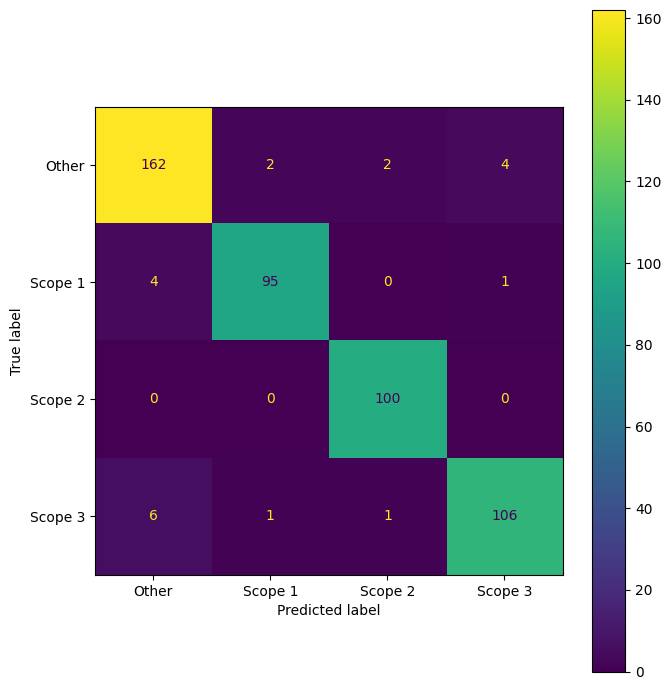

In [47]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=list(label2id.keys())

)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax)

plt.tight_layout()

plt.show()

##**Load Saved Model**

In [48]:
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    BEST_MODEL_DIR
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    BEST_MODEL_DIR
)

loaded_model.eval()

print("Best model loaded successfully.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Best model loaded successfully.


## **All seed results**

In [49]:
results_df = pd.DataFrame(all_results)

display(results_df)

print("=" * 60)
print("Mean")
print("=" * 60)

display(
    results_df.mean(numeric_only=True)
)

print("=" * 60)
print("Std")
print("=" * 60)

display(
    results_df.std(numeric_only=True)
)

,seed,train_loss,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_weighted_precision,train_weighted_recall,train_weighted_f1,eval_loss,...,eval_weighted_recall,eval_weighted_f1,test_loss,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,42,0.001785,0.999742,0.999688,0.999725,0.999706,0.999742,0.999742,0.999742,0.292437,...,0.960744,0.960516,0.317859,0.956612,0.959269,0.958191,0.958602,0.956627,0.956612,0.956504
1,123,0.017954,0.995349,0.994970,0.995798,0.995370,0.995382,0.995349,0.995354,0.212219,...,0.956612,0.956281,0.292434,0.946281,0.951834,0.947949,0.949327,0.947041,0.946281,0.946108
2,2026,0.004249,0.999225,0.999358,0.999267,0.999312,0.999225,0.999225,0.999225,0.276153,...,0.958678,0.958500,0.308627,0.958678,0.962545,0.959662,0.960802,0.959106,0.958678,0.958610
3,3407,0.003050,0.998708,0.998699,0.998717,0.998706,0.998711,0.998708,0.998708,0.252839,...,0.954545,0.954238,0.307720,0.954545,0.955384,0.955583,0.955417,0.954276,0.954545,0.954350
4,8888,0.027537,0.990956,0.989810,0.992271,0.990996,0.991048,0.990956,0.990959,0.254186,...,0.948347,0.947832,0.258928,0.946281,0.950784,0.947949,0.948957,0.946664,0.946281,0.946070


Mean


,0
seed,2897.200000
train_loss,0.010915
train_accuracy,0.996796
train_macro_precision,0.996505
train_macro_recall,0.997156
train_macro_f1,0.996818
train_weighted_precision,0.996822
train_weighted_recall,0.996796
train_weighted_f1,0.996797
eval_loss,0.257567


Std


,0
seed,3631.698046
train_loss,0.011352
train_accuracy,0.003689
train_macro_precision,0.004191
train_macro_recall,0.003131
train_macro_f1,0.003678
train_weighted_precision,0.003650
train_weighted_recall,0.003689
train_weighted_f1,0.003687
eval_loss,0.030214


## **Test predict**

In [50]:
sample = """
Purchased electricity consumed during the reporting year
"""

inputs = loaded_tokenizer(

    sample,

    return_tensors="pt",

    truncation=True,

    max_length=MAX_LENGTH

)

with torch.no_grad():

    outputs = loaded_model(**inputs)

pred = outputs.logits.argmax(-1).item()

probs = torch.softmax(
    outputs.logits,
    dim=1
)

confidence = probs.max().item()

print("=" * 60)
print("Prediction")
print("=" * 60)

print("Text:")
print(sample)

print()

print("Predicted Label :", id2label[pred])

print("Confidence      :", round(confidence,4))

Prediction
Text:

Purchased electricity consumed during the reporting year


Predicted Label : Scope 2
Confidence      : 0.9999


# Reuse

In [56]:
# # ==========================================================
# # Reuse ClimateBERT Scope Classifier
# # ==========================================================

# import os
# import json
# import torch
# import torch.nn.functional as F

# from transformers import (
#     AutoTokenizer,
#     AutoModelForSequenceClassification
# )

# MODEL_PATH = "/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier"

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # ----------------------------------------------------------
# # Load tokenizer
# # ----------------------------------------------------------

# tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

# # ----------------------------------------------------------
# # Load model
# # ----------------------------------------------------------

# model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_PATH
# )

# model.to(DEVICE)
# model.eval()

# # ----------------------------------------------------------
# # Load label mapping
# # ----------------------------------------------------------

# with open(
#     os.path.join(
#         MODEL_PATH,
#         "label_mapping.json"
#     ),
#     "r",
#     encoding="utf-8"
# ) as f:

#     mapping = json.load(f)

# label2id = mapping["label2id"]

# id2label = {
#     int(k): v
#     for k, v in mapping["id2label"].items()
# }

# print("Model loaded successfully.")
# print(label2id)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Model loaded successfully.
{'Other': 0, 'Scope 1': 1, 'Scope 2': 2, 'Scope 3': 3}


In [57]:
# # ==========================================================
# # Prediction Function
# # ==========================================================

# def predict_scope(
#     text,
#     max_length=256
# ):

#     inputs = tokenizer(
#         text,
#         return_tensors="pt",
#         truncation=True,
#         max_length=max_length
#     )

#     inputs = {
#         k: v.to(DEVICE)
#         for k, v in inputs.items()
#     }

#     with torch.no_grad():

#         outputs = model(**inputs)

#         probs = F.softmax(
#             outputs.logits,
#             dim=-1
#         )[0]

#     pred_id = torch.argmax(probs).item()

#     prediction = id2label[pred_id]

#     confidence = probs[pred_id].item()

#     probabilities = {

#         id2label[i]: round(
#             probs[i].item(),
#             4
#         )

#         for i in range(len(probs))
#     }

#     return {

#         "prediction": prediction,

#         "confidence": confidence,

#         "probabilities": probabilities

#     }

In [58]:
# sample = """
# Purchased electricity consumed during the reporting year.
# """

# result = predict_scope(sample)

# print(result)

{'prediction': 'Scope 2', 'confidence': 0.9999122619628906, 'probabilities': {'Other': 0.0, 'Scope 1': 0.0, 'Scope 2': 0.9999, 'Scope 3': 0.0001}}


In [59]:
# # ==========================================================
# # Batch Prediction
# # ==========================================================

# def predict_batch(texts):

#     results = []

#     for text in texts:

#         pred = predict_scope(text)

#         results.append(pred)

#     return results

In [60]:
# # Example
# texts = [
#     "Purchased electricity consumed.",
#     "Direct fuel combustion.",
#     "Business travel by employees."
# ]

# results = predict_batch(texts)

# for r in results:
#     print(r)

{'prediction': 'Scope 2', 'confidence': 0.9999265670776367, 'probabilities': {'Other': 0.0, 'Scope 1': 0.0, 'Scope 2': 0.9999, 'Scope 3': 0.0}}
{'prediction': 'Scope 1', 'confidence': 0.999845027923584, 'probabilities': {'Other': 0.0001, 'Scope 1': 0.9998, 'Scope 2': 0.0, 'Scope 3': 0.0}}
{'prediction': 'Scope 3', 'confidence': 0.9998065829277039, 'probabilities': {'Other': 0.0001, 'Scope 1': 0.0001, 'Scope 2': 0.0001, 'Scope 3': 0.9998}}
